Nombre y apellidos = Alfonso Íñiguez Cortés \
gmail: aic35@alu.ua.es \
Grupo: 3

## NetworkX

`NetworkX` es una librería que nos permite trabajar en grafos...

## 1. Instalación

Para empezar, vamos a instalar e importar `NetworkX` para poder trabajar con ella el resto del cuaderno:

In [2]:
try:
    !pip install networkx
    !pip show networkx
except:
    f"No se ha podido descargar la librería"

Name: networkx
Version: 3.2.1
Summary: Python package for creating and manipulating graphs and networks
Home-page: 
Author: 
Author-email: Aric Hagberg <hagberg@lanl.gov>
License: 
Location: /opt/miniconda3/envs/discrete_brain/lib/python3.9/site-packages
Requires: 
Required-by: torch


## 2. Importación de paquetes

Una vez instalada, vamos a importarla para usarla en nuestro código:

In [3]:
import networkx as nx

## 3. Creación de un grafo

Vamos a crear nuestro primer grafo usando esta librería. Para ello, tenemos la función ``Graph()``. Vamos a poner un ejemplo de ello creando un grafo vacío:

In [4]:
grafo = nx.Graph()
print(grafo)

Graph with 0 nodes and 0 edges


El anterior grafo era uno no dirigido, pero `NetworkX` nos ofrece una función para crear grafos dirigidos. Vamos a explicar antes la diferencia entre ambos tipos de grafos:

- Grafo dirigido -> Utilizan flechas para indicar una dirección específica en sus aristas (unidireccionales)
- Grafo NO dirigido -> Utilizan lineas simples que representan relaciones bidireccionales. 

La función que usamos para crear grafos dirigido, usamos `DiGraph()`. Vamos a poner un ejemplo creando un grafo vacío:

In [5]:
grafo_dirigido = nx.DiGraph()
print(grafo)

Graph with 0 nodes and 0 edges


### 3.1 Creación de un grafo a partir de una matriz Numpy 

De momento solo hemos creando grafos vacíos, el siguiente paso es crearlos con datos. En este apartado vamos a crear un grafo a partir de una matriz numpy. Para ello, usamos nuevamente las funciones básicas: `Graph()` y `DiGraph()`. Vamos a crear un ejemplo de como crear un grafo dirigido y no dirigido usando una matriz Numpy:

In [6]:
import numpy as np

matriz_numpy = np.array([[1,0],[1,1]])
grafo = nx.Graph(matriz_numpy)
print(grafo)
print(grafo.nodes)
print(grafo.edges)

Graph with 2 nodes and 3 edges
[0, 1]
[(0, 0), (0, 1), (1, 1)]


Notamos como hemos creado un grafo con 2 nodos y dos aristas. El funcionamiento es el siguiente:

```python
matriz_numpy = np.array([[1,0],[0,1]])
grafo = nx.Graph(matriz_numpy)
```
Vamos a explicar como se crea este grafo a partir de esos datos. Cuando usamos una array de numpy, tenemos esto : [1,0] y [1,1]. Esos dos elementos son los nodos. Por eso nos dice que hemos creando un grafo `with 2 nodes`. Ahora que sabemos donde se definen los nodos, vamos a explicar de donde salen las aristas. Para entenderlo bien, vamos a fijranos en los nodos:

- Nodo "0": [1,0] -> De este nodo, va a salir una arista puedo que tenemos un 1. Para ser más precisos, esta arista (edge) es la (0,0), puesto que el 1 esta en el nodo "0" y dentro de este nodo esta en la posición "0". 
- Nodo "1": De que obtenemos 2 aristas, puesto que hay dos "1". Estos se encuentran en el nodo "1" y en las posiciones "0" y "1", por eso obtenemos las aristas (0,1) y (1,1).

Un apunte más para entender la distinción entre grafos dirigidos y no dirigidos es la arista (0,1). Recordamos que está en el nodo "1" y en la posición "0", entonces: ¿Por qué no es (1,0) y es (0,1)? Esto sería así si se tratara de un grafo dirigido, pero al tratarse de un grafo no dirigido las aristas tienen sentido bidireccional y se representa como (0,1).

Vamos a crear ahora un ejemplo de un grafo dirigido usando una matirz numpy para notar esta distinción:

In [7]:
import numpy as np

matriz_numpy = np.array([[1,0],[1,1]])
grafo = nx.DiGraph(matriz_numpy)
print(grafo)
print(grafo.nodes)
print(grafo.edges)

DiGraph with 2 nodes and 3 edges
[0, 1]
[(0, 0), (1, 0), (1, 1)]


Notamos como ahora sí tenemos la aristas como (1,0) y no como (0,1). Para obtener las aristas y nodos de un grafo usamos las funciones:

- .nodes: Devuelve los nodos
- .edges: Devuelve las aristas

Otra función que podemos usar es `nx.adjacency_matrix()` junto con `todense()`, que realizan respectivamente: devuelve la matriz de adyacencia de un grafo (formato matriz dispersa) y convierte una matriz dispersa a matriz densa. Vamos a ver el funcionamiento:

In [8]:
print('Matriz de adyacencia del grafo:')
print(nx.adjacency_matrix(grafo))
print('Matriz densa:')
print(nx.adjacency_matrix(grafo).todense())

Matriz de adyacencia del grafo:
  (0, 0)	1
  (1, 0)	1
  (1, 1)	1
Matriz densa:
[[1 0]
 [1 1]]


### 3.2 Creación de un grafo a partir de un DataFrame de Pandas

Otra forma de cración de grafos es usando un DataFrame. Vamos a poner un ejemplo :

In [9]:
import pandas as pd

df = pd.DataFrame({'from': [0, 1, 2, 3], 'to': [1, 0, 3, 2]}) 
grafo = nx.from_pandas_edgelist(df, 'from', 'to') 
print(grafo)
print(grafo.nodes) 
print(grafo.edges) 

Graph with 4 nodes and 2 edges
[0, 1, 2, 3]
[(0, 1), (2, 3)]


El funcionamiento es el siguiente:

Creamos el DataFrame usando un diccionario que contiene 2 claves: `from` y `to`:
- from -> Definimos los nodos (en este caso creamos 4 nodos que son el 0, el 1...)
- to -> Definimos las conexiones entre los nodos (aristas): Tenemos dos listas, en la primera tenemos los nodos y en la segunda a que nodos se conectan los originales. Las conexiones de definen por la posición, es decir, en nuestro ejemplo tenemos:

```python
nodos: list = [0,1,2,3]
nodos_a_los_que_se_conectan_los_nodos: list = [1,0,3,2]
```

Tenemos que el nodo "0" se conceta con el nodo "1" (ambos estan en la primera posición)
Luego el nodo "1" se conecta con el "0" (como esta arista ya estaba definida (0,1), no se guarda)
Luego tenemos que el nodo "2" se conceta con el nodo "3" (dando luegar a la arista (2,3))

Y así sucesivamente se van definiendo los nodos y las aristas.

In [10]:
print('Conexiones')
print(nx.adjacency_matrix(grafo).todense())

Conexiones
[[0 1 0 0]
 [1 0 0 0]
 [0 0 0 1]
 [0 0 1 0]]


Vamos a explicar la matriz de adyacencia con mayor claridad: ...

### 3.3 Adición de nodos

`NetworkX` nos ofrece la función `add_nodes()`, la cual nos permite insertar a nuestro grafo un nodo. Recibe como parámetro el índice del nodo que queramos añadir. Para poder añadir varios nodos a la vez, tenemos la función `add_nodes_from([])` que recibe los índices (dentro de una lista) de los nodos a instertar. Vamos a crear un grafo vacío y luego vamos a añadir nodos a modo de ejemplo:

In [11]:
# Creación grafo vacío
grafo = nx.Graph() # Lo hacemos no dirigido
print(f'Grafo vacío: \n{grafo}\n')
# Añadimos un nodo
grafo.add_node(1)  # Añadimos el nodo con el índice "1"
print(f'Grafo después de la inserción: \n{grafo} | Nodos->  {grafo.nodes} | Aristas-> {grafo.edges}\n')

# Podemos añadir varios nodos a la vez
grafo.add_nodes_from([10,11,12,13])
print(f'Grafo después de la inserción de varios nodos: \n{grafo} | Nodos->  {grafo.nodes} | Aristas-> {grafo.edges}')

Grafo vacío: 
Graph with 0 nodes and 0 edges

Grafo después de la inserción: 
Graph with 1 nodes and 0 edges | Nodos->  [1] | Aristas-> []

Grafo después de la inserción de varios nodos: 
Graph with 5 nodes and 0 edges | Nodos->  [1, 10, 11, 12, 13] | Aristas-> []


Además, los nodos de un grafo pueden guardar atributos. Estos se refieren a información adicional de cada nodo. Para guardarlos, podemos emplear un diccionario. Una vez que tenemos creados los atributos, para asignárselos a los nodos usamos la función `set_node_atributtes` que recibe los siguente parámetros:

- grafo
- diccionario con los atributos
- nombre del atributo

Es decir:
```python
nx.set_node_atributtes(G, color, 'color')
```
Después de esa instrucción, cad nodo del grafo 'G' va a tener un atributo llamado 'color'. Vamos a ver un ejemplo creando varios atributos para un grafo:

In [12]:
# Creamos grafo vacío
G = nx.Graph()
# Añadimos los nodos para asignarles los atributos
nodos = [1,2,3,4]
G.add_nodes_from(nodos)
# Creamos los atributos (usando diccionarios)
edad = {1: 19, 2: 20, 3: 31, 4: 49, 5: 54} 
grupo = {1: [1, 2, 3], 2: [4, 5, 6], 3: [7, 8, 9], 4: [10, 11, 12], 5: [13, 14, 15]} 
name = {1: 'Álvaro', 2: 'Bernardo', 3: 'Carlos', 4: 'David', 5: 'Eduardo'}
id = {1: 1, 2: 2, 3: 3, 4: 4, 5: 5} 

nx.set_node_attributes(G, edad, 'edad')  # Asigamos atributo al grafo
print('Añadimos atributo edad:')
print(G.nodes[1])
print('Información de la edad del primer nodo:')
print(G.nodes[1]['edad'])
print()

nx.set_node_attributes(G, grupo, 'grupo') # Asigamos atributo al grafo
print('Añadimos atributo grupo:')
print(G.nodes[2]) 
print('Información del grupo del segundo nodo:')
print(G.nodes[2]['grupo']) 
print()

nx.set_node_attributes(G, name, 'name') # Asigamos atributo al grafo
print('Añadimos atributo name:')
print(G.nodes[3]) 
print('Información del nombre del tercer nodo:')
print(G.nodes[3]['name']) 
print()

nx.set_node_attributes(G, id, 'id') # Asigamos atributo al grafo
print('Añadimos atributo id:')
print(G.nodes[4]) 
print('Información del ID del cuatro nodo:')
print(G.nodes[4]['id']) 

Añadimos atributo edad:
{'edad': 19}
Información de la edad del primer nodo:
19

Añadimos atributo grupo:
{'edad': 20, 'grupo': [4, 5, 6]}
Información del grupo del segundo nodo:
[4, 5, 6]

Añadimos atributo name:
{'edad': 31, 'grupo': [7, 8, 9], 'name': 'Carlos'}
Información del nombre del tercer nodo:
Carlos

Añadimos atributo id:
{'edad': 49, 'grupo': [10, 11, 12], 'name': 'David', 'id': 4}
Información del ID del cuatro nodo:
4


### 3.4 Adición de aristas

Ahora que hemos visto como agregar nodos, vamos a esutidar como podemos agregar arsitas a nuestros grafos. Para ello nuevamente tenemos las funciones:

- `add_edge()` para añadir una arista
- `add_edges_from([])` para añadir un conjunto de aristas

Vamos a verlo con un ejemplo:

In [13]:
# Creación grafo con algunos nodos (no dirigido)
grafo = nx.Graph()
nodos = [1,2,3]
grafo.add_nodes_from(nodos)
print(f'Grafo \n{grafo}\n')

# Añadimos una arista
grafo.add_edge(1,2) 
print(f'Grafo después de la inserción: \n{grafo} | Nodos->  {grafo.nodes} | Aristas-> {grafo.edges}\n')

# Podemos añadir varias arsitas a la vez
grafo.add_edges_from([(2,3),(1,3)])
print(f'Grafo después de la inserción de varias aristas: \n{grafo} | Nodos->  {grafo.nodes} | Aristas-> {grafo.edges}')

Grafo 
Graph with 3 nodes and 0 edges

Grafo después de la inserción: 
Graph with 3 nodes and 1 edges | Nodos->  [1, 2, 3] | Aristas-> [(1, 2)]

Grafo después de la inserción de varias aristas: 
Graph with 3 nodes and 3 edges | Nodos->  [1, 2, 3] | Aristas-> [(1, 2), (1, 3), (2, 3)]


Además, las aristas de un grafo también pueden guardar atributos. Estas se refieren a información adicional sobre la conexión entre dos nodos, como por ejemplo un peso, una distancia o un tipo de relación. Para guardarlos, podemos emplear nuevamente diccionarios. Una vez que tenemos creados los atributos, para asignárselos a las aristas usamos la función ``set_edge_attributes``, que recibe los siguientes parámetros:

- grafo
- diccionario con los atributos
- nombre del atributo

Es decir:
```python
nx.set_edge_atributtes(G, color, 'color')
```
Después de esa instrucción, cada arista del grafo 'G' va a tener un atributo llamado 'color'. Vamos a ver un ejemplo creando varios atributos para un grafo:

In [14]:
# Creamos grafo vacío
G = nx.Graph()
# Añadimos nodos
nodos = [1,2,3,4]
G.add_nodes_from(nodos)

# Añadimos algunas aristas
aristas = [(1,2), (2,3), (3,4), (4,1)]
G.add_edges_from(aristas)

# Creamos atributos para las aristas (diccionarios)
peso = {(1,2): 5, (2,3): 3, (3,4): 7, (4,1): 2}          
tipo = {(1,2): 'amigo', (2,3): 'compañero', (3,4): 'vecino', (4,1): 'familia'}  
longitud = {(1,2): 10, (2,3): 15, (3,4): 8, (4,1): 12}   

# Asignamos los atributos al grafo
nx.set_edge_attributes(G, peso, 'peso')
print('Añadimos atributo peso:')
print(G.edges[1,2])
print('Información del peso de la arista (1,2):')
print(G.edges[1,2]['peso'])
print()

nx.set_edge_attributes(G, tipo, 'tipo')
print('Añadimos atributo tipo:')
print(G.edges[2,3])
print('Información del tipo de la arista (2,3):')
print(G.edges[2,3]['tipo'])
print()

nx.set_edge_attributes(G, longitud, 'longitud')
print('Añadimos atributo longitud:')
print(G.edges[3,4])
print('Información de la longitud de la arista (3,4):')
print(G.edges[3,4]['longitud'])

Añadimos atributo peso:
{'peso': 5}
Información del peso de la arista (1,2):
5

Añadimos atributo tipo:
{'peso': 3, 'tipo': 'compañero'}
Información del tipo de la arista (2,3):
compañero

Añadimos atributo longitud:
{'peso': 7, 'tipo': 'vecino', 'longitud': 8}
Información de la longitud de la arista (3,4):
8


### 3.5 Eliminación de nodos y aristas

Para la eliminación de nodos y/o aristas, `NetWorkX` nos ofrece las siguiente funciones:
(consideramos G -> > grafo)
- G.remove_node()  -> Elimina un único nodo el cual recibe como parámetro
- G.remove_nodes_from([]) -> Elimina una lista de nodos la cual recibe como parámetro
- G.remove_edge() -> Elimina una única arista la cual recibe como parámetro
- G.remove_edges_from([]) -> Elimina una lista de aristas la cual recibe como parámetro

Vamos a ver un ejemplo del funcionamiento:

In [15]:
# Creamos un grafo
G = nx.Graph()

# Añadimos aristas y nodos
nodos = [1,2,3,4,5,6,7]
G.add_nodes_from(nodos)

edges = [(1,3),(1,2),(3,4),(6,7),(2,5),(5,6),(2,6),(4,7)]
G.add_edges_from(edges)

# Funcionamiento
print(f'Grafo inicial\n---------------\n{G}')
print(G.nodes)
print(G.edges)

# Eliminamos nodos
G.remove_node(1)  # Eliminamos nodo 1
G.remove_nodes_from([3,5]) # Eliminamos nodos 3 y 5
print(f'\nGrafo después de eliminar los nodos 1, 3 y 5')
print(G.nodes)
print(G.edges)

# Eliminamos aristas
G.remove_edge(2,6)  # Eliminamos arista '2,6'
G.remove_edges_from([(4,7),(6,7)]) # Eliminamos nodos 3 y 5
print(f'\nGrafo después de eliminar las arsitas restantes')
print(G.nodes)
print(G.edges)

Grafo inicial
---------------
Graph with 7 nodes and 8 edges
[1, 2, 3, 4, 5, 6, 7]
[(1, 3), (1, 2), (2, 5), (2, 6), (3, 4), (4, 7), (5, 6), (6, 7)]

Grafo después de eliminar los nodos 1, 3 y 5
[2, 4, 6, 7]
[(2, 6), (4, 7), (6, 7)]

Grafo después de eliminar las arsitas restantes
[2, 4, 6, 7]
[]


Por último, nos damos cuenta que al eliminar un nodo eliminamos también cualquier arsita que este conectada a este de automáticamente. Es por eso que, en el ejemplo, después de eliminar varios nodos hemos eliminado con ellos varias aristas

### 3.6 Acceso a nodos y aristas

Podemos acceder de forma individual o grupal a los nodos y aristas de nuestro grafo. Para ello, `NetworkX` nos ofrece varias opciones. En este apartado vamos a esutidar algunas de ellas, concretamente:

- G.nodes: Devuelve una lista con los nodos del grafo (G)
- G.edges: Devuelve uha lista con las aristas del grafo (G)

Si queremos acceder a algún nodo o arsita en concreto, podemos realizar lo siguiente:
```python
idx_node = 2
idx_edge = 3
list(G.nodes)[idx_node]
list(G.edges)[idx_edge]
```
Es decir, listamos los nodos o las aristas y accedemos a ellos a través de su posición (índice) que tengan en la lista. \
Vamos a poner en ejemplo de acceso:

In [16]:
# Creamos un grafo
G = nx.Graph()

# Añadimos aristas y nodos
nodos = [1,2,3,4,5,6,7]
G.add_nodes_from(nodos)

edges = [(1,3),(1,2),(3,4),(6,7),(2,5),(5,6),(2,6),(4,7)]
G.add_edges_from(edges)

# Funcionamiento (acceso)
print(f'Grafo\n-------\n{G}\n')
# Nodos
print('Nodos:')
print(f'Lista con los nodos del grafo: {G.nodes}')
print(f'Tercer nodo del grafo: {list(G.nodes)[2]}\n')

# Aristas
print('Aristas:')
print(f'Lista con las aristas del grafo: {G.edges}')
print(f'Primera arista del grafo: {list(G.edges)[0]}')

Grafo
-------
Graph with 7 nodes and 8 edges

Nodos:
Lista con los nodos del grafo: [1, 2, 3, 4, 5, 6, 7]
Tercer nodo del grafo: 3

Aristas:
Lista con las aristas del grafo: [(1, 3), (1, 2), (2, 5), (2, 6), (3, 4), (4, 7), (5, 6), (6, 7)]
Primera arista del grafo: (1, 3)


### 3.7 Acceso a los atributos de los nodos y aristas

No solo podemos acceder a nodos y aristas, si no que también podemos acceder a sus atributos. En `NetWorkX`, cada nodo/arista es internamente un diccionario. Para acceder a un atributos usamos la siguiente sintaxis:
```python
G.nodes[]  # Devuelve un diccionario que incluye todos los atributos de ese nodo
G.nodes[][nombre atributo] # Devuelve un atributo concreto (dentro del diccionario)
```
Tanto para los nodos como las aristas se usa la misma sintaxis. Vamos a poner un ejemplo de acceso a atributos para comprender mejor el funcionamiento:

In [17]:
# Creamos grafo vacío
G = nx.Graph()
# Añadimos los nodos y aristas para asignarles los atributos
nodos = [1,2,3,4]
G.add_nodes_from(nodos)
edges = [(1,2),(2,3),(3,4),(4,1)]
G.add_edges_from(edges)

# Creamos los atributos (usando diccionarios)
# Nodes
edad = {1: 19, 2: 20, 3: 31, 4: 49, 5: 54} 
id = {1: 1, 2: 2, 3: 3, 4: 4, 5: 5} 
# Edges
tipo = {(1,2): 'amigo', (2,3): 'compañero', (3,4): 'vecino', (4,1): 'familia'}  
longitud = {(1,2): 10, (2,3): 15, (3,4): 8, (4,1): 2}

# Asignamos los atributos de los nodos
nx.set_node_attributes(G, edad, 'edad')  
nx.set_node_attributes(G, id, 'id') 

# Asignamos los atributos de los nodos
nx.set_edge_attributes(G, tipo, 'tipo')
nx.set_edge_attributes(G, longitud, 'longitud')

# Acceso a atributos
print(f'Grafo\n------\n{G}')
print(f'Nodos: {G.nodes}')
print(f'Aristas: {G.edges}')
print()

# Atributos nodos
for nodo in G.nodes:  # Bucle que recorre los nodos
    print(f'Nodo {nodo} -> Atributos: {G.nodes[nodo]}')
    # Atributos de los nodos
    print(f'Edad: {G.nodes[nodo]["edad"]}, ID: {G.nodes[nodo]["id"]}\n')

# Atributos aristas
for a, b in G.edges:  # Recorremos todas las aristas
    print(f'Arista ({a}, {b}) -> Atributos: {G.edges[a, b]}')
    # Acceso a los atributos de la arista
    print(f'Tipo: {G.edges[a, b]["tipo"]}, Longitud: {G.edges[a, b]["longitud"]}\n')

Grafo
------
Graph with 4 nodes and 4 edges
Nodos: [1, 2, 3, 4]
Aristas: [(1, 2), (1, 4), (2, 3), (3, 4)]

Nodo 1 -> Atributos: {'edad': 19, 'id': 1}
Edad: 19, ID: 1

Nodo 2 -> Atributos: {'edad': 20, 'id': 2}
Edad: 20, ID: 2

Nodo 3 -> Atributos: {'edad': 31, 'id': 3}
Edad: 31, ID: 3

Nodo 4 -> Atributos: {'edad': 49, 'id': 4}
Edad: 49, ID: 4

Arista (1, 2) -> Atributos: {'tipo': 'amigo', 'longitud': 10}
Tipo: amigo, Longitud: 10

Arista (1, 4) -> Atributos: {'tipo': 'familia', 'longitud': 2}
Tipo: familia, Longitud: 2

Arista (2, 3) -> Atributos: {'tipo': 'compañero', 'longitud': 15}
Tipo: compañero, Longitud: 15

Arista (3, 4) -> Atributos: {'tipo': 'vecino', 'longitud': 8}
Tipo: vecino, Longitud: 8



### 3.8 Acceso a los vecinos de un nodo

Los vecinos de un nodo son todos aquellos nodos que están conectados a este mediante una arista `NetworkX` nos permite obtener los vecinos de un nodo. Para ello nos ofrece la función `G.neighbors()` (siendo G un grafo). Esta función recibe como argumento el nodo del que se van a obtener los vecinos. El funcionamiento es el siguiente:

```python
nodo = 2
vecinos = list(G.negihbors(nodo))
```
Notamos como usamos `list`. Esto ocurre porque la función `neighbors()` no devuelve, si no un iterador. Cuando usamos `list`, podemos ver los vecinos en una lista \
Vamos a poner un ejemplo del funciamiento de esta funcion:

In [18]:
# Creamos el grafo
G = nx.Graph()

# Añadimos nodos y aristas
nodes = [1,5,10]
edges = [(1,5),(5,10)]

G.add_nodes_from(nodes)
G.add_edges_from(edges)

# Vecinos del nodo 5
neighbors = list(G.neighbors(5))
print(f'Nodos: {G.nodes}')
print(f'Aristas: {G.nodes}')
print(f'Vecinos del nodo "5": {neighbors}')

Nodos: [1, 5, 10]
Aristas: [1, 5, 10]
Vecinos del nodo "5": [1, 10]


### 3.9 Acceso al grado de un nodo

El grado de un nodo se refiere a el número de aristas que están conectadas a dicho nada. Relacionándolo con el apartado anterior, el grado de un nodo es el número de vecinos que tiene. Para obtenerl el grado, disponemos de la función `degree()`, la cual recibe como parámetro el nodo del que queremos obtener la explicación. Vamos a poner un ejemplo del funcionamiento:

In [19]:
# Creamos el grafo
G = nx.Graph()

# Añadimos nodos y aristas
nodes = [1,5,10,15,20]
edges = [(1,5),(5,10),(10,15),(5,20)]

G.add_nodes_from(nodes)
G.add_edges_from(edges)

# Vecinos del nodo 5
neighbors = list(G.neighbors(5))
print(f'Nodos: {G.nodes}')
print(f'Aristas: {G.nodes}')
print(f'Vecinos del nodo "5": {neighbors}')

# Grado del nodo 5
print(f'Grado del nodo 5: {G.degree(5)}')

Nodos: [1, 5, 10, 15, 20]
Aristas: [1, 5, 10, 15, 20]
Vecinos del nodo "5": [1, 10, 20]
Grado del nodo 5: 3


### 3.10 Acceso al número de nodos y aristas

`NetworkX` también nos ofrece funciones para conocer el número de nodos y aristas de nuestro grafo. Estas son (considerando "G" como un grafo):
- G.number_of_nodes(): Devuelve el número de nodos
- G.number_of_edges(): Devuelve el número de aristas

Vamos a poner un ejemplo para comprender mejor el funcionamiento de estas funciones:

In [20]:
# Creamos el grafo
G = nx.Graph()

# Añadimos nodos y aristas
nodes = [1,5,10,15,20,25]
edges = [(1,5),(5,10),(5,15),(1,10),(20,25),(1,15)]

G.add_nodes_from(nodes)
G.add_edges_from(edges)

# Grafo
print(f'Grafo\n------\n{G}')
print(f'Nodos: {G.nodes}')
print(f'Aristas: {G.edges}\n\nInformación del grafo\n---------------------')

# Nodos
print(f'Número de nodos: {G.number_of_nodes()}')

# Aristas
print(f'Número de aristas: {G.number_of_edges()}')

Grafo
------
Graph with 6 nodes and 6 edges
Nodos: [1, 5, 10, 15, 20, 25]
Aristas: [(1, 5), (1, 10), (1, 15), (5, 10), (5, 15), (20, 25)]

Información del grafo
---------------------
Número de nodos: 6
Número de aristas: 6


### 3.11 Acceso a la matriz de adyacencia

La matriz de adyacencia es una forma de representar el grafo usando una tabla. Dicha tabla nos proporciona la información acerca de las conexiones entre nodos (de un grafo). La tabla (o matriz) tiene las siguentes propiedades:
- Las filas y columnas representan nodos
- En cada posición (i,j), se pone un "1" si hay una arista entre los nodos i y j, si no, se coloca un "0"

Para obtener la tabla de adyacencia de un grafo, usamos la función `adjacency_matrix()` que tiene el siguiente funcionamiento:
- Recibe como parámetro el grafo a evaluar
- Devuelve una matriz en formato disperso, es decir, en lugar de mostrar una matriz con unos o ceros, solo nos muestra las posiciones donde hay valores que no sean cero. 

Si queremos obtener la tabla de adyacencia como una matriz normal, usamos la función `todense()`, que recibe como parámetro la matriz dispersa y la convierte en una matriz normal. \
Vamos a ver un ejemplo para comprender este apartado mejor:

In [83]:
# Creamos un grafo vacío
G = nx.Graph() 

# Añadimos nodos y aristas
nodos = [0,1,2,3]
edges = [(1,3),(3,0),(1,2)]

G.add_nodes_from(nodos) 
G.add_edges_from(edges) 

# Funcionamiento
print(f'Grafo inicial\n{G}\nNodos: {G.nodes}\nAristas:{G.edges}\n')

# Matriz dispersa
print('Matrtiz de adyacencia (formato disperso):')
print(nx.adjacency_matrix(G)) 
print()

# Matriz normal 
print('Matrtiz de adyacencia (formato normal):')
print(nx.adjacency_matrix(G).todense()) 

Grafo inicial
Graph with 4 nodes and 3 edges
Nodos: [0, 1, 2, 3]
Aristas:[(0, 3), (1, 3), (1, 2)]

Matrtiz de adyacencia (formato disperso):
  (0, 3)	1
  (1, 2)	1
  (1, 3)	1
  (2, 1)	1
  (3, 0)	1
  (3, 1)	1

Matrtiz de adyacencia (formato normal):
[[0 0 0 1]
 [0 0 1 1]
 [0 1 0 0]
 [1 1 0 0]]


### 3.12 Acceso a la matriz de grados

La matriz de grados es una matriz que guarda el grado de cada nodo del grafo. Esta matriz solo guarda valores en la digonal, dichos valores se refieren a los grados de los distintos nodos del grafo. Es decir, si tenemos un grafo con 7 nodos, la matriz de grados será de 7x7 (diagonal tiene 7 valores). Para calcular la matriz de grados podemos seguir el siguiente procedimiento:

1. Definimos el grafo
2. Obtenemos los grados de sus nodos
3. Creamos una matriz de ceros y vamos guardando los grados en su diagonal

Vamos a ver un ejemplo:

In [87]:
# Creamos el grafo
G = nx.Graph()

# Añadimos nodos y arsitas
nodes = [1,2,3,4,5,6,7]
edges = [(1,4),(2,4),(2,5),(5,7),(3,6),(1,6)]
G.add_nodes_from(nodes)
G.add_edges_from(edges)

# Obtener una lista con los grados de los nodos del grafo
grados = dict(G.degree())

# Creamos la matriz de grados (con 0 de momento) para
# añadir los grados a su diagonal
n = len(G.nodes())
matriz_grados = np.zeros((n, n))

for i, node in enumerate(sorted(G.nodes())):     # Recorremos los nodos del grafo (usamos "enumerate")
    matriz_grados[i, i] = grados[node]    # para obtener (por cada iteración) el nodo y su posición


# Funcionamiento
print(f'Grafo inicial\n{G}\nNodos: {G.nodes}\nAristas:{G.edges}\n')
print(f'Matriz de grados:\n {matriz_grados}') 

Grafo inicial
Graph with 7 nodes and 6 edges
Nodos: [1, 2, 3, 4, 5, 6, 7]
Aristas:[(1, 4), (1, 6), (2, 4), (2, 5), (3, 6), (5, 7)]

Matriz de grados:
 [[2. 0. 0. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 2. 0. 0. 0.]
 [0. 0. 0. 0. 2. 0. 0.]
 [0. 0. 0. 0. 0. 2. 0.]
 [0. 0. 0. 0. 0. 0. 1.]]


### 3.13 Acceso a la matriz laplaciana

La matriz laplaciana se refiere a una matriz que se obteien combinando la matriz de grados y la matriz de adyacencia. Se obtiene con la siguiente fórmula: 
$$
L = D - A
$$ 
donde:
- **L**: matriz laplaciana
- **A**: matriz de adyacencia
- **D**: matriz laplaciana

Aunque se puede calcular usa la fórmula, `NetworkX` nos ofrece la función `laplacian_matrix()` para obtenerla. Esta función recibe como parámetro el grafo a evaluar y devuelve una matriz en formato disperso. Nuevamenete, podemos usar `todense()` para pasar de matriz de dispersa a matriz normal en caso de que se prefiera así. \
Vamos a verlo con un ejemplo:

In [84]:
# Creamos un grafo vacío
G = nx.Graph() 

# Añadimos nodos y aristas
nodos = [0,1,2,3]
edges = [(1,3),(3,0),(1,2)]

G.add_nodes_from(nodos) 
G.add_edges_from(edges) 

# Funcionamiento
print(f'Grafo inicial\n{G}\nNodos: {G.nodes}\nAristas:{G.edges}\n')

# Matriz dispersa
print('Matrtiz laplaciana (formato disperso):')
print(nx.laplacian_matrix(G)) 
print()

# Matriz normal 
print('Matrtiz laplaciana (formato normal):')
print(nx.laplacian_matrix(G).todense()) 

Grafo inicial
Graph with 4 nodes and 3 edges
Nodos: [0, 1, 2, 3]
Aristas:[(0, 3), (1, 3), (1, 2)]

Matrtiz laplaciana (formato disperso):
  (0, 0)	1
  (0, 3)	-1
  (1, 1)	2
  (1, 2)	-1
  (1, 3)	-1
  (2, 1)	-1
  (2, 2)	1
  (3, 0)	-1
  (3, 1)	-1
  (3, 3)	2

Matrtiz laplaciana (formato normal):
[[ 1  0  0 -1]
 [ 0  2 -1 -1]
 [ 0 -1  1  0]
 [-1 -1  0  2]]


## 4. Visualiazión de un grafo

Hasta ahora hemos estudiado como crear, modificar y obtener información de un grafo. El siguiente paso es graficar estos grafos. Para visualizar el grafo, vamos a emplear la bilioteca de la anterior práctica: `Matplotlib`. Vamos a importarla entonces para pode trabajar con ella:

In [89]:
import matplotlib.pyplot as plt

Además de dicha librería, vamos a usar la función `draw()` que nos ofrece `NetorkX`. Esta función recibe como parámetros:
- El grafo que queremos visualizar
- Diccionario con las posiciones de cada nodo (2D) donde las claves son los nodos del grafo y los valores son las coordenadas de cada uno en formato (x, y)

Para calcular las posición de los nodos, podemos usar la función `spring_layaout()` que recibe como parámetero el grafo (para calcular las posiciones de los nodos) y una semilla para que el resultado sea reproducible. Esta función nos devuelve el diccionario con los nodos y sus posiciones. Para visualizar la figura de manera óptima, usamos algunas funciones de `Matplotlib` como pueden ser:
- **plt.figure** -> Definir tamaño de la figura
- **plt.show** -> Mostrar el grafo \
(entre otras)

Vamos a crear y visualizar un grafo a modo de ejemplo:

Posiciones de los nodos:
Nodo: 0 | Posición: [ 0.50946557 -0.87111192]
Nodo: 1 | Posición: [-0.49160079 -0.86825448]
Nodo: 2 | Posición: [-1.         -0.00163099]
Nodo: 3 | Posición: [-0.50934285  0.87104377]
Nodo: 4 | Posición: [0.49195431 0.86866618]
Nodo: 5 | Posición: [0.99952376 0.00128745]


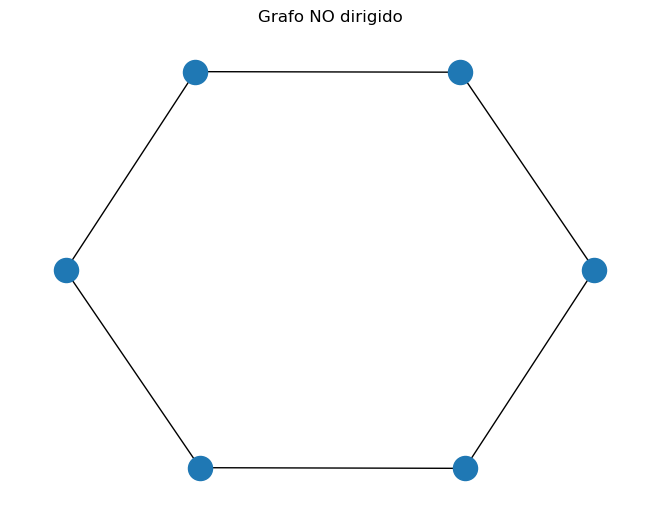

Posiciones de los nodos:
Nodo: 0 | Posición: [-0.53055807  0.23165074]
Nodo: 1 | Posición: [-0.34647913  1.        ]
Nodo: 2 | Posición: [-0.14745429  0.32623451]
Nodo: 3 | Posición: [ 0.56080562 -0.16001187]
Nodo: 4 | Posición: [ 0.63021244 -0.79941466]
Nodo: 5 | Posición: [-0.16652656 -0.59845871]


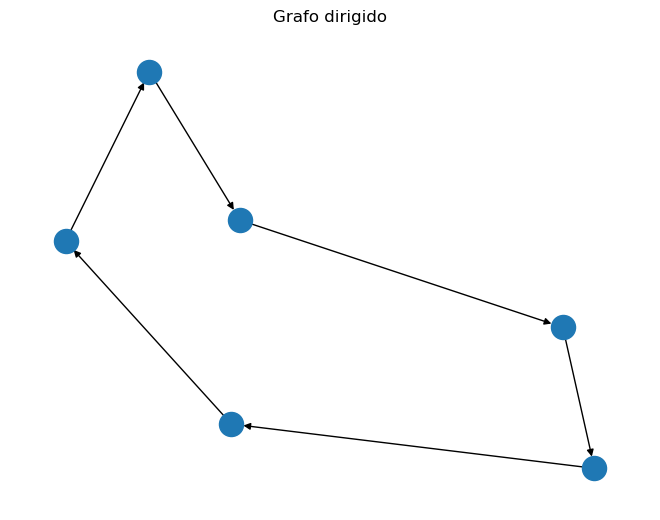

In [122]:
# Creamos el grafo (no dirigido)
G = nx.Graph()

# Añadimos nodos y aristas
nodos = [0,1,2,3,4,5]
edges = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,0)]   # Péntagono

G.add_nodes_from(nodos) 
G.add_edges_from(edges) 

# Calculamos la posición de los nodos
posiciones = nx.spring_layout(G, seed = 44)

print('Posiciones de los nodos:')
for node, position in posiciones.items():
    print(f'Nodo: {node} | Posición: {position}')

# Dibujamos el grafo con las posiciones y los nodos
nx.draw(G, posiciones)

# Mostramos por pantalla
plt.title('Grafo NO dirigido')
plt.show()

#-----------------------------------------------#
# Creamos el grafo (no dirigido)
G = nx.DiGraph()

# Añadimos nodos y aristas
nodos = [0,1,2,3,4,5]
edges = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,0)]   # Péntagono

G.add_nodes_from(nodos) 
G.add_edges_from(edges) 

# Calculamos la posición de los nodos
posiciones = nx.spring_layout(G, seed = 44)

print('Posiciones de los nodos:')
for node, position in posiciones.items():
    print(f'Nodo: {node} | Posición: {position}')

# Dibujamos el grafo con las posiciones y los nodos
nx.draw(G, posiciones)

# Mostramos por pantalla
plt.title('Grafo dirigido')
plt.show()

Esa forma es la visaulización básica de grafos. Sin embargo, podemos mejorar la visualización mediante distintos parámetros de la función `draw()`. Dichos parámetros nos van a permitir personalizar la aparencia de los nodos, aristas, etiquetas... 

Algunas personalizaciones que podemos aplicar son las siguientes:

```python
nx.draw(G, pos,
        node_color='red',     # Color de los nodos
        node_size=500,        # Tamaño de los nodos
        node_shape='o',       # Forma de los nodos (círculo)
        alpha=0.8,            # Opacidad de los nodos
        edge_color='black',   # Color de las aristas
        width=2,              # Grosor de las aristas
        style='dashed',       # Estilo de las aristas (línea discontinua)
        font_size=12,         # Tamaño de la letra de las etiquetas
        font_color='black',   # Color de la letra
        font_weight='bold',   # Grosor de la letra
        font_family='serif',  # Tipo de letra
        with_labels=True)     # Muestra las etiquetas de los nodos
```
De esta forma logramos un gráfico más claro y estético. Vamos a ver un ejemplo empleando dichas personalizaciones:

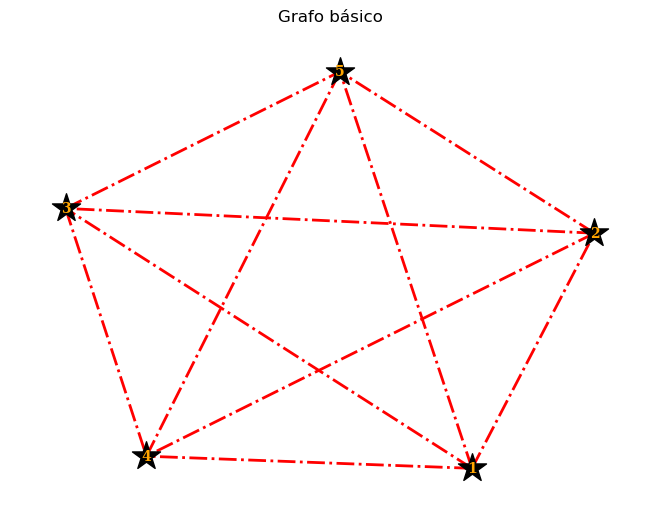

In [120]:
# Creamos el grafo (no dirigido)
G = nx.Graph()

# Añadimos nodos y aristas
nodes = [1,2,3,4,5]
edges = [
    (1,2),(2,3),(3,4),(4,5),(5,1),  # pentágono exterior
    (1,3),(2,4),(3,5),(4,1),(5,2)   # diagonales formando estrella interna
]

G.add_nodes_from(nodes) 
G.add_edges_from(edges) 

# Calculamos la posición de los nodos
posiciones = nx.spring_layout(G, seed = 44)

# Personalizaciones
COLOR_NODOS = 'black'
TAMAÑO_NODOS = 450
FORMA_NODOS = '*'
OPACIDAD_NODOS = 1        
COLOR_ARISTAS = 'red'
GROSOR_ARISTAS = 2          
ESTILO_ARISTAS = '-.'
TAMAÑO_ETIQUETAS = 10
COLOR_LETRA = 'orange'
GROSOR_LETRA = 'bold'
TIPO_LETRA = 'serif'
MOSTRAR_ETIQUETAS = True

# Dibujamos el grafo
nx.draw(G, posiciones, 
        node_color=COLOR_NODOS,
        node_size=TAMAÑO_NODOS, 
        node_shape=FORMA_NODOS,
        alpha=OPACIDAD_NODOS, 
        edge_color=COLOR_ARISTAS,
        width=GROSOR_ARISTAS, 
        style=ESTILO_ARISTAS, 
        font_size=TAMAÑO_ETIQUETAS,
        font_color=COLOR_LETRA, 
        font_weight=GROSOR_LETRA,
        font_family=TIPO_LETRA, 
        with_labels=MOSTRAR_ETIQUETAS)

# Mostramos por pantalla
plt.title('Grafo básico')
plt.show()

Ahora que sabemos como crear visualizaciones de grafo y como modificarlas, podemos crear grafos mucho más avanzados. Vamos a crear y visualizar un grafo complejo utilizando todo lo que hemos visto hasta el momento en este cuaderno (nodos, aristas, atributos, personalizaciones...)

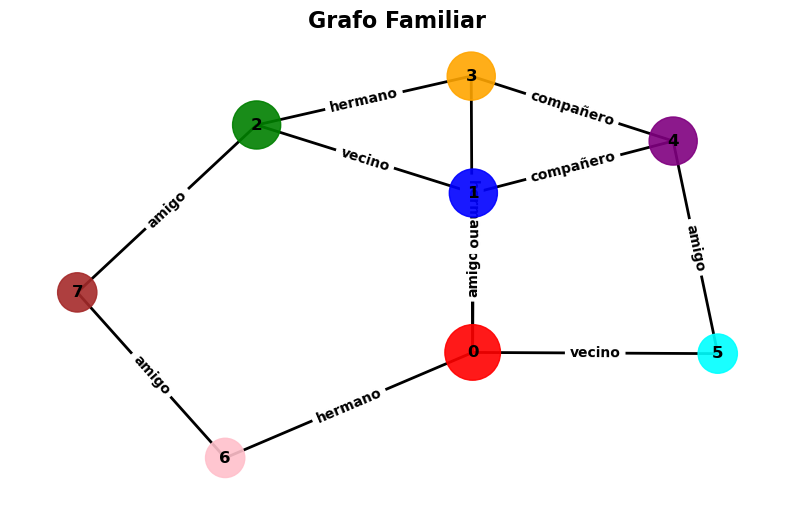

In [152]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(10,6))

# Grafo
G = nx.Graph()
nodes = list(range(8))  # Quitamos los nodos 8 y 9
G.add_nodes_from(nodes)

# Aristas (quitamos las que involucraban a 8 y 9)
edges = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,0),(0,3),(1,4),
         (6,7),(2,7),(0,6)]
G.add_edges_from(edges)

# Nombres de nodos
labels_dict = {0:'Ana',1:'Leo',2:'Mia',3:'Tom',4:'Eva',5:'Max',
               6:'Luz',7:'Ian'}  # Sin Noa y Sof
nx.set_node_attributes(G, labels_dict, 'label')

# Relación de aristas
edge_labels = {(0,1):'amigo', (1,2):'vecino', (2,3):'hermano', (3,4):'compañero',
               (4,5):'amigo', (5,0):'vecino', (0,3):'hermano', (1,4):'compañero',
               (6,7):'amigo', (2,7):'amigo', (0,6):'hermano'}
nx.set_edge_attributes(G, edge_labels, 'relation')

# Layout circular para evitar superposición
pos = nx.spring_layout(G, seed=41)

# Colores nodos
color_map = {'Ana':'red','Leo':'blue','Mia':'green','Tom':'orange','Eva':'purple','Max':'cyan',
             'Luz':'pink','Ian':'brown'}
colors = [color_map[G.nodes[n]['label']] for n in G.nodes()]

# Tamaño nodos según grado
sizes = [G.degree[n]*400 for n in G.nodes()]

# Estilo aristas
edge_styles = ['solid' for _ in G.edges()]

# Dibujar
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=2, edge_color='black', style=edge_styles)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_weight='bold')

plt.title('Grafo Familiar', fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

## 5. Ejercicios

Este cuaderno es un informe acerca de lo aprendido en esta práctica

### 5.2 Ejercicio 2

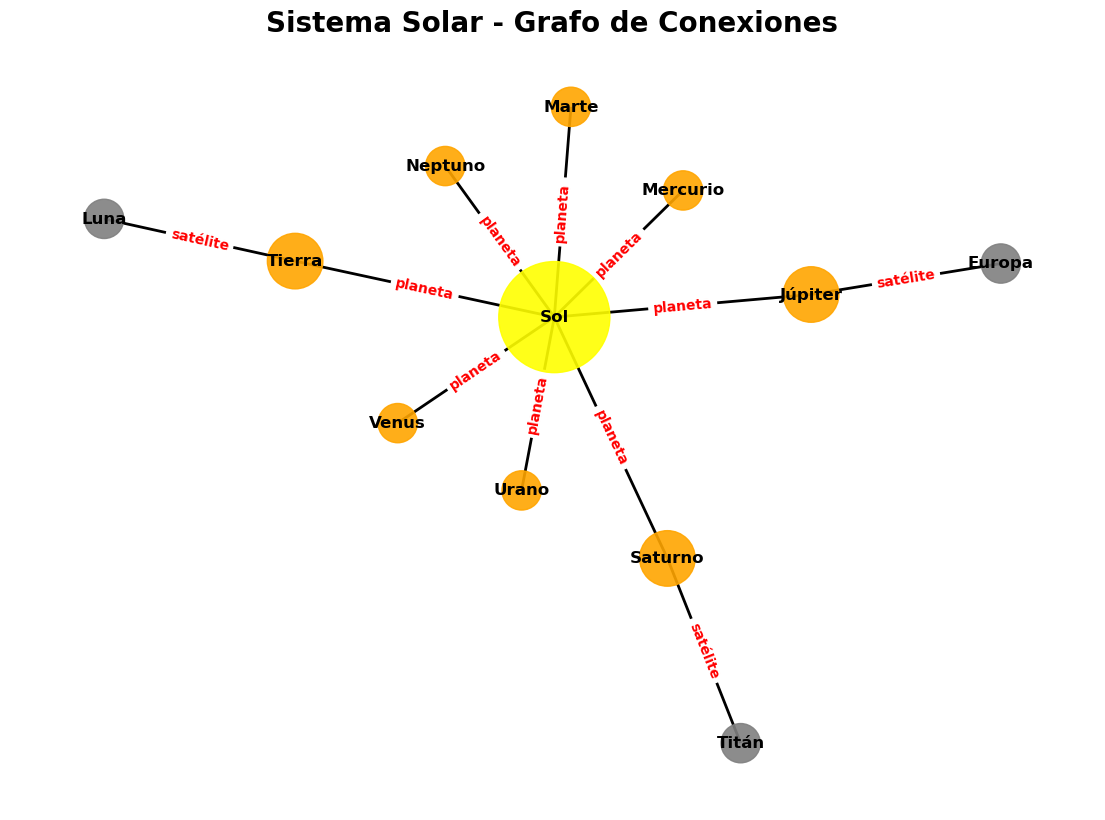

In [164]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Leemos el CSV
df = pd.read_csv('dataset.csv')
G = nx.Graph()

# Añadimos nodos con atributo tipo y aristas
for i, fila in df.iterrows():
    G.add_node(fila["Nombre"], tipo=fila["Tipo"])  # Nodo con tipo
    for j in str(fila["Conexiones"]).split(','):
        nombre_conexion = df.loc[df["ID"] == int(j), "Nombre"].values[0]
        # Determinar tipo de arista
        tipo_u = fila["Tipo"]
        tipo_v = df.loc[df["ID"] == int(j), "Tipo"].values[0]
        if (tipo_u == 'Estrella' and tipo_v == 'Planeta') or (tipo_v == 'Estrella' and tipo_u == 'Planeta'):
            edge_type = 'planeta'
        elif (tipo_u == 'Planeta' and tipo_v == 'Satélite') or (tipo_v == 'Planeta' and tipo_u == 'Satélite'):
            edge_type = 'satélite'
        else:
            edge_type = 'otros'
        G.add_edge(fila["Nombre"], nombre_conexion, tipo=edge_type)

# Posiciones de los nodos
pos = nx.spring_layout(G, seed=42)

# Colores según tipo
color_map = {'Estrella':'yellow', 'Planeta':'orange', 'Satélite':'gray'}
node_colors = [color_map[G.nodes[n]['tipo']] for n in G.nodes()]

# Tamaños según grado (más grandes)
node_sizes = [G.degree[n]*800 for n in G.nodes()]

# Dibujar nodos
plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)

# Dibujar aristas
nx.draw_networkx_edges(G, pos, width=2, edge_color='black')

# Dibujar etiquetas de nodos
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Dibujar etiquetas de aristas (el "tipo")
edge_labels = nx.get_edge_attributes(G, 'tipo')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=10, font_weight='bold')

plt.title("Sistema Solar - Grafo de Conexiones", fontsize=20, fontweight='bold')
plt.axis('off')
plt.show()

## como se hacía en clase :

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dataset.csv')
G = nx.Graph()

for i, fila in df.iterrows():
    G.add_node(i) # 0,1,2,3 
    for j in fila["Conexiones"]:
        G.add_edge(i,j)

nx.draw(G, with_labels=True)
plt.show()

#hola